2025-04-12 17:59:07.582250: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-12 17:59:07.608313: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-12 17:59:07.608354: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-12 17:59:07.609457: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-12 17:59:07.615554: I tensorflow/core/platform/cpu_feature_guar

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
File: 2DS.jpg - Predicted class: daisy with probability 0.98


I0000 00:00:1744444756.882531  331773 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


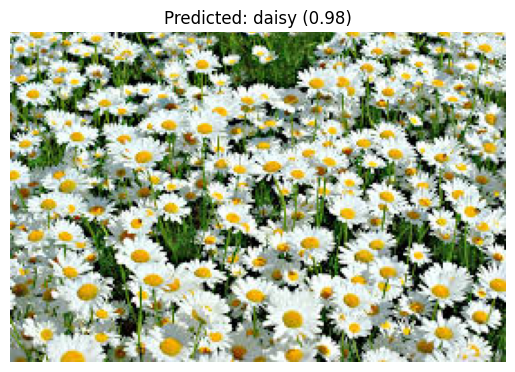

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
File: 4TL.jpg - Predicted class: tulips with probability 0.58


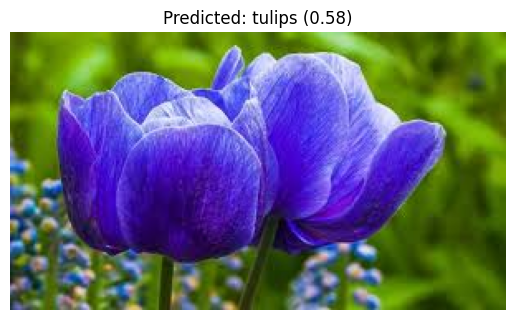

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
File: 2DD.jpg - Predicted class: dandelion with probability 0.67


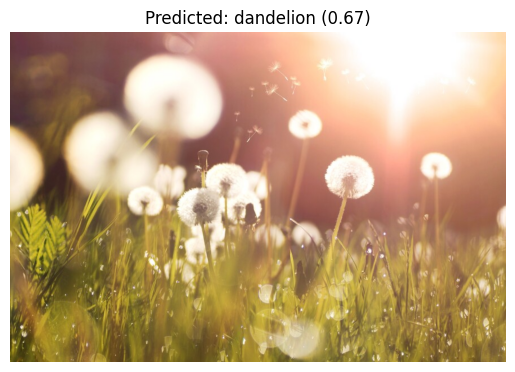

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
File: 3DS.jpg - Predicted class: roses with probability 0.35


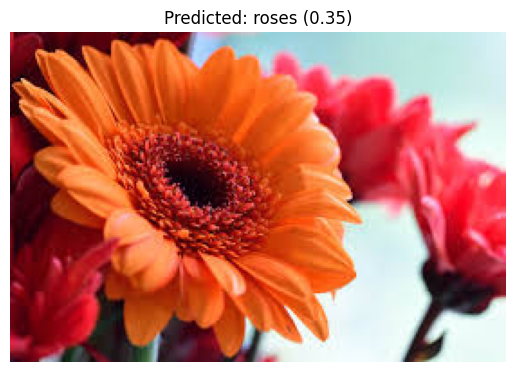

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
File: 3RS.jpg - Predicted class: roses with probability 0.73


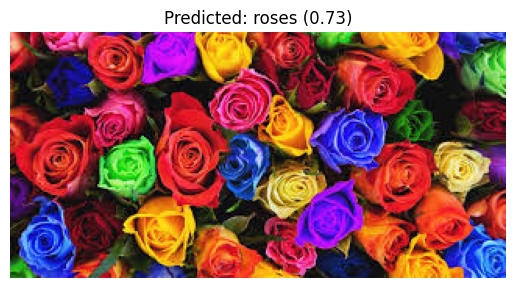

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
File: 2TL.jpg - Predicted class: tulips with probability 0.90


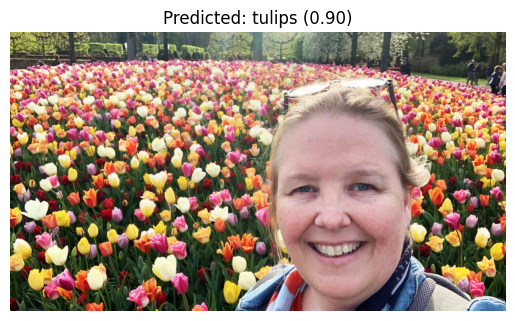

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
File: 1DD.jpg - Predicted class: dandelion with probability 0.84


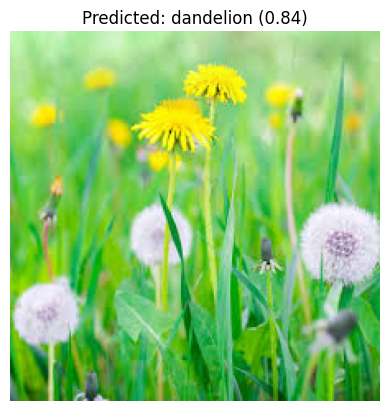

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
File: 1TL.jpg - Predicted class: daisy with probability 0.56


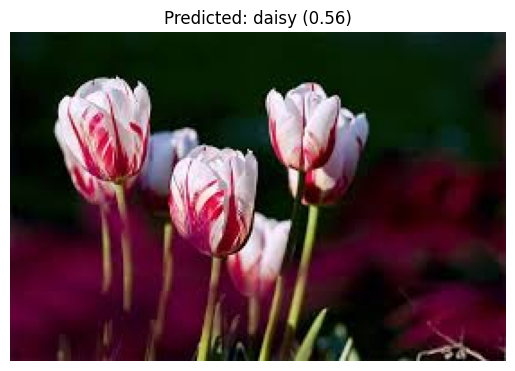

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
File: 2SF.jpg - Predicted class: sunflowers with probability 0.73


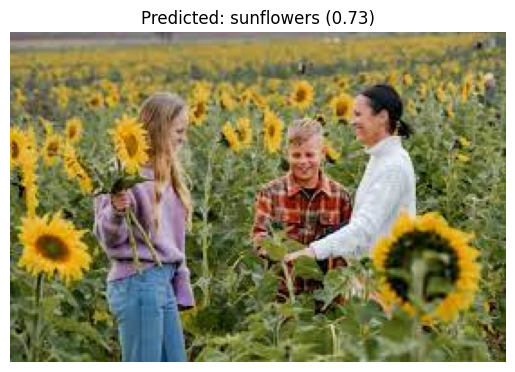

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
File: 3TL.jpg - Predicted class: tulips with probability 0.48


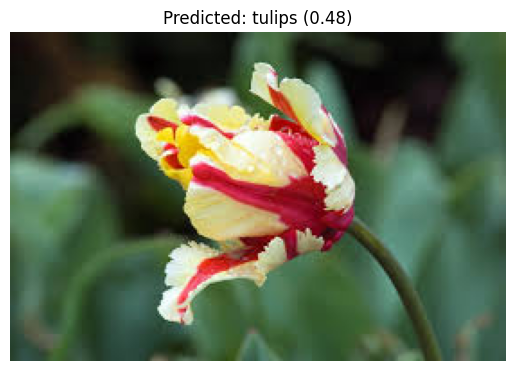

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
File: 1SF.jpg - Predicted class: sunflowers with probability 0.98


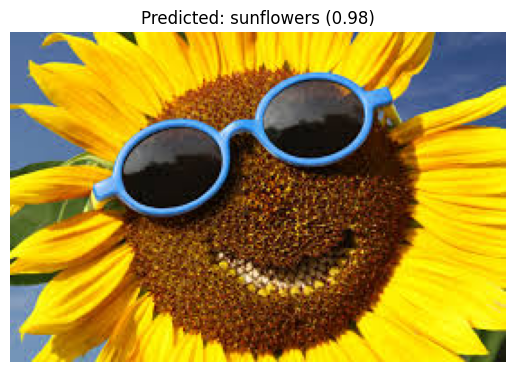

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
File: 4RS.jpg - Predicted class: roses with probability 0.74


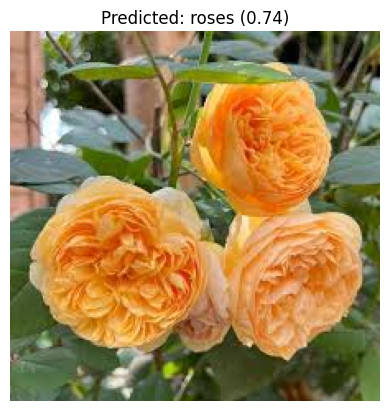

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
File: 1RS.jpg - Predicted class: roses with probability 0.95


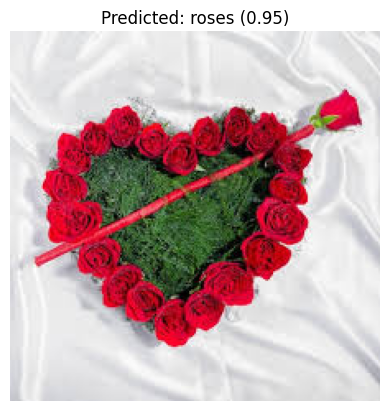

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
File: 3SF.jpg - Predicted class: sunflowers with probability 0.87


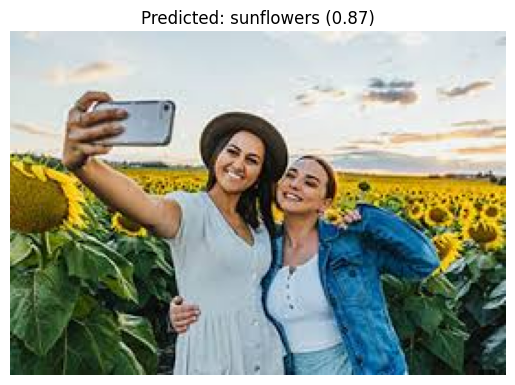

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
File: 3DD.jpg - Predicted class: dandelion with probability 0.94


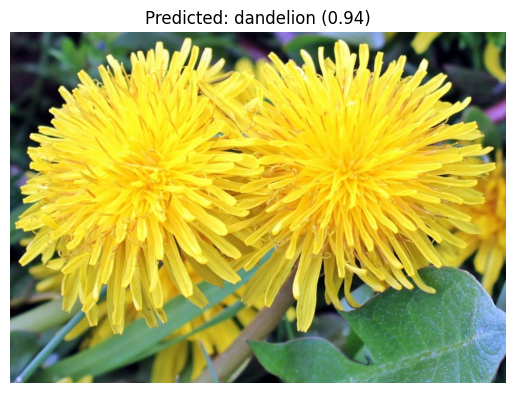

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
File: 2RS.jpg - Predicted class: roses with probability 0.92


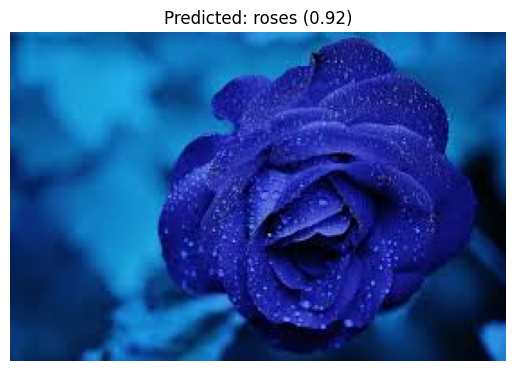

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
File: 1(DS).jpg - Predicted class: sunflowers with probability 0.98


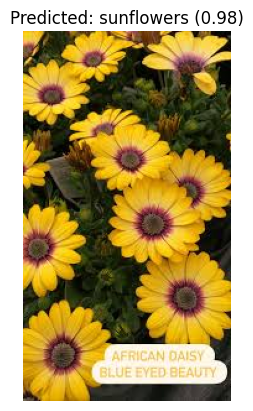

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt

def load_trained_model(model_path):
    '''
    Load the trained model from the specified path.
    '''
    model = tf.keras.models.load_model(model_path)
    return model

def preprocess_image(image_path, target_size=(224, 224)):
    '''
    Preprocess the image to match the input format expected by the model.
    
    Parameters:
        - image_path: str, path to the image file
        - target_size: tuple, size to which the image is resized
    
    Returns:
        - preprocessed_image: numpy array, preprocessed image
    '''
    image = load_img(image_path, target_size=target_size)
    image = img_to_array(image)
    image = (image / 127.5) - 1  # Normalize to [-1, 1]
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    return image

def predict_flower_class(model, image, class_names, base_model=None):
    '''
    Predict the class of the flower image using the trained model.
    
    Parameters:
        - model: tf.keras.Model, trained model
        - image: numpy array, preprocessed image
        - class_names: list of str, class names
        - base_model: tf.keras.Model, base model for feature extraction (optional)
    
    Returns:
        - predicted_class: str, the predicted class name
        - predicted_proba: float, the probability of the predicted class
    '''
    if base_model is not None:
        # Extract features using the base model
        image = base_model.predict(image)
    
    predictions = model.predict(image)
    predicted_class_idx = np.argmax(predictions, axis=1)[0]
    predicted_class = class_names[predicted_class_idx]
    predicted_proba = np.max(predictions, axis=1)[0]
    return predicted_class, predicted_proba

def main(folder_path, model_path, class_names, is_accelerated=False):
    '''
    Main function to load the model, preprocess the images in a folder, make predictions,
    and display the results.
    
    Parameters:
        - folder_path: str, path to the folder containing image files
        - model_path: str, path to the trained model
        - class_names: list of str, class names
        - is_accelerated: bool, whether the model is for accelerated learning
    '''
    # Load the trained model
    model = load_trained_model(model_path)
    
    # If accelerated learning model, load the base model
    base_model = None
    if is_accelerated:
        base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
        base_model.trainable = False  # Ensure the base model is not trainable
    
    # Iterate over all images in the folder
    for filename in os.listdir(folder_path):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(folder_path, filename)
            # Preprocess the input image
            image = preprocess_image(image_path)
            
            # Make a prediction
            predicted_class, predicted_proba = predict_flower_class(model, image, class_names, base_model)
            
            # Display the result
            print(f"File: {filename} - Predicted class: {predicted_class} with probability {predicted_proba:.2f}")
            
            # Plot the image
            original_image = load_img(image_path)
            plt.imshow(original_image)
            plt.title(f"Predicted: {predicted_class} ({predicted_proba:.2f})")
            plt.axis('off')
            plt.show()

if __name__ == "__main__":
    # Define the paths
    folder_path = "/home/imhaom/CAB420_Machine_Learning/CAB320/MLtesting"  # Path to the folder containing test images
    model_path = "/home/imhaom/CAB420_Machine_Learning/CAB320/trained_model_transfer.h5"
    
    # Define the class names (ensure these match the classes used in training)
    class_names = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
    
    # Indicate if the model is for accelerated learning
    is_accelerated = False  # Set to True for accelerated learning model
    
    # Run the main function
    main(folder_path, model_path, class_names, is_accelerated)